# Comprehensive Cohort EDA - 30-Day Readmission Analysis

**Purpose:** Comprehensive exploratory data analysis of MIMIC-IV cohort for 30-day readmission prediction, mirroring `ehr/cohort_eda.py` workflow for both HPC and Colab environments.

**Target Cohorts:**
- Short-stay transitional cases (LOS ≤7d)  
- Cardio-renal/sepsis long stays (LOS ≥15d with AKI/HF/sepsis clusters)

**Clinical Focus:** Identify high-risk patient populations and modifiable risk factors for readmission prevention.

## 0. Environment Setup & Data Contracts

- PhysioNet paths mounted read-only (Colab: use Google Drive mirror or upload subsets)
- Local intermediates: `data/interim/cohort.csv`, derived CSVs in `data/interim/readmit_analysis/`
- Runtime toggles (`SKIP_LABS`, `SKIP_MEDS`) for memory/time management

In [7]:
import warnings
warnings.filterwarnings('ignore')

import datetime as dt
from pathlib import Path
from typing import Dict, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Temporarily set working directory to repo root
import os
os.chdir('/share/crsp/lab/pkaiser/ddlin/mids/datasci-266/mimic_nlp/')  # Set WD to repo root
print(f"Working directory set to: {os.getcwd()}")  # Confirmation


# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data paths
DATA_ROOT = Path('data/interim')
COHORT_PATH = DATA_ROOT / 'cohort.csv'
ANALYSIS_DIR = DATA_ROOT / 'readmit_analysis'
PHYSIONET_ROOT = Path('physionet.org/files/mimiciv/3.1/hosp')

DIAGNOSES_PATH = PHYSIONET_ROOT / 'diagnoses_icd.csv.gz'
LABEVENTS_PATH = PHYSIONET_ROOT / 'labevents.csv.gz'
PRESCRIPTIONS_PATH = PHYSIONET_ROOT / 'prescriptions.csv.gz'

TODAY = dt.datetime.now().strftime('%Y-%m-%d')

# Runtime configuration
SKIP_LABS = False  # Set to True for faster execution
SKIP_MEDS = False  # Set to True for faster execution

print(f"Analysis date: {TODAY}")
print(f"Data paths initialized")

Working directory set to: /share/crsp/lab/pkaiser/ddlin/mids/datasci-266/mimic_nlp
Analysis date: 2025-11-08
Data paths initialized


## 1. Load Cohort & Basic Statistics

In [8]:
# Load cohort with essential columns
cohort_cols = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 'length_of_stay_days',
    'readmitted_within_window', 'readmission_gap_in_days', 'age_at_admit',
    'gender', 'race', 'admission_type', 'discharge_location', 'discharge_note_text'
]

print("Loading cohort...")
cohort = pd.read_csv(COHORT_PATH, usecols=cohort_cols, parse_dates=['admittime', 'dischtime'])

# Basic statistics
print(f"Total admissions: {len(cohort):,}")
print(f"Unique patients: {cohort['subject_id'].nunique():,}")
print(f"Overall readmission rate: {cohort['readmitted_within_window'].mean():.1%}")
print(f"Mean age: {cohort['age_at_admit'].mean():.1f} years")
print(f"Mean LOS: {cohort['length_of_stay_days'].mean():.1f} days")

# LOS segmentation
LOS_BINS = [0, 4, 7, 10, 14, 21, float('inf')]
LOS_LABELS = ['<=4d', '5-7d', '8-10d', '11-14d', '15-21d', '>=22d']
cohort['los_segment'] = pd.cut(
    cohort['length_of_stay_days'], bins=LOS_BINS, labels=LOS_LABELS, include_lowest=True
)

cohort.head()

Loading cohort...
Total admissions: 184,154
Unique patients: 94,532
Overall readmission rate: 17.1%
Mean age: 63.7 years
Mean LOS: 7.4 days


,subject_id,hadm_id,admittime,dischtime,length_of_stay_days,admission_type,discharge_location,readmission_gap_in_days,readmitted_within_window,age_at_admit,gender,race,discharge_note_text,los_segment
0,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,2.222222,EW EMER.,HOME,NaN,False,52,F,WHITE,\nName: ___ Unit No: _...,<=4d
1,10000117,27988844,2183-09-18 18:10:00,2183-09-21 16:30:00,2.930556,OBSERVATION ADMIT,HOME HEALTH CARE,NaN,False,57,F,WHITE,\nName: ___ Unit No: ___\n...,<=4d
2,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,4.707639,URGENT,HOME HEALTH CARE,NaN,False,86,M,WHITE,\nName: ___ Unit No: ___\n \...,5-7d
3,10000826,20032235,2146-12-05 19:07:00,2146-12-12 16:30:00,6.890972,EW EMER.,HOME,6.047917,True,32,F,WHITE,\nName: ___. Unit No: ___\n \nAdm...,5-7d
4,10000826,21086876,2146-12-18 17:39:00,2146-12-24 19:55:00,6.094444,DIRECT EMER.,HOME,6.200000,True,32,F,WHITE,\nName: ___. Unit No: ___\n \nAdm...,5-7d


## 2. ICD-Based Condition Flags

**Clinical Rationale:** Identify high-risk clinical conditions associated with readmission
- **AKI (Acute Kidney Injury):** N17, N19, N185, 584, 586
- **Heart Failure:** I50, I13, I11, 428  
- **Sepsis:** A41, R652, R651, 9959, 038
- **Hyponatremia:** E871, 2761
- **Post-hemorrhagic Anemia:** D62, 2851

In [9]:
# Define condition prefixes (ICD-9/10 codes)
condition_prefixes = {
    'acute_kidney_injury': ['N17', 'N19', 'N185', '584', '586'],
    'heart_failure': ['I50', 'I13', 'I11', '428'],
    'hyponatremia': ['E871', '2761'],
    'posthemorrhagic_anemia': ['D62', '2851'],
    'sepsis': ['A41', 'R652', 'R651', '9959', '038'],
}

print("Processing ICD codes for condition flags...")
hadm_set = set(cohort['hadm_id'])
condition_hits = {name: set() for name in condition_prefixes}

# Process diagnoses in chunks for memory efficiency
for chunk in pd.read_csv(DIAGNOSES_PATH, chunksize=500_000, usecols=['hadm_id', 'icd_code']):
    chunk = chunk[chunk['hadm_id'].isin(hadm_set)]
    if chunk.empty:
        continue
    
    # Clean and standardize ICD codes
    icd = chunk['icd_code'].astype(str).str.upper().str.replace('.', '', regex=False)
    
    # Check each condition
    for name, prefixes in condition_prefixes.items():
        mask = np.zeros(len(icd), dtype=bool)
        for prefix in prefixes:
            mask |= icd.str.startswith(prefix).to_numpy()
        if mask.any():
            condition_hits[name].update(chunk.loc[mask, 'hadm_id'])

# Apply condition flags to cohort
for name, hadms in condition_hits.items():
    cohort[f'has_{name}'] = cohort['hadm_id'].isin(hadms)

# Create composite flags
cohort['has_any_cardiorenal_sepsis'] = cohort[
    ['has_acute_kidney_injury', 'has_heart_failure', 'has_hyponatremia',
     'has_posthemorrhagic_anemia', 'has_sepsis']
].any(axis=1)

cohort['has_aki_and_hf'] = cohort['has_acute_kidney_injury'] & cohort['has_heart_failure']
cohort['cardiorenal_sepsis_long'] = (cohort['length_of_stay_days'] >= 15) & cohort['has_any_cardiorenal_sepsis']
cohort['long_stay_no_cardiorenal'] = (cohort['length_of_stay_days'] >= 15) & (~cohort['has_any_cardiorenal_sepsis'])

# Display condition prevalence
condition_summary = pd.DataFrame({
    'Condition': list(condition_prefixes.keys()),
    'Prevalence': [cohort[f'has_{name}'].mean() for name in condition_prefixes.keys()],
    'Count': [cohort[f'has_{name}'].sum() for name in condition_prefixes.keys()]
})
condition_summary['Prevalence_pct'] = (condition_summary['Prevalence'] * 100).round(1)
condition_summary

Processing ICD codes for condition flags...


,Condition,Prevalence,Count,Prevalence_pct
0,acute_kidney_injury,0.199550,36748,20.0
1,heart_failure,0.211394,38929,21.1
2,hyponatremia,0.077457,14264,7.7
3,posthemorrhagic_anemia,0.081986,15098,8.2
4,sepsis,0.063116,11623,6.3


## 3. Length of Stay & Readmission Analysis

Readmission Rates by Length of Stay Segment:


,los_segment,admissions,readmits,readmit_rate,cardiorenal_share,readmit_rate_pct,cardiorenal_share_pct
0,<=4d,64505,8633,0.133835,0.000000,13.4,0.0
1,5-7d,60210,10291,0.170918,0.000000,17.1,0.0
2,8-10d,26874,5123,0.190630,0.000000,19.1,0.0
3,11-14d,14625,3024,0.206769,0.000000,20.7,0.0
4,15-21d,9781,2206,0.225539,0.486044,22.6,48.6
5,>=22d,8159,2188,0.268170,0.667974,26.8,66.8


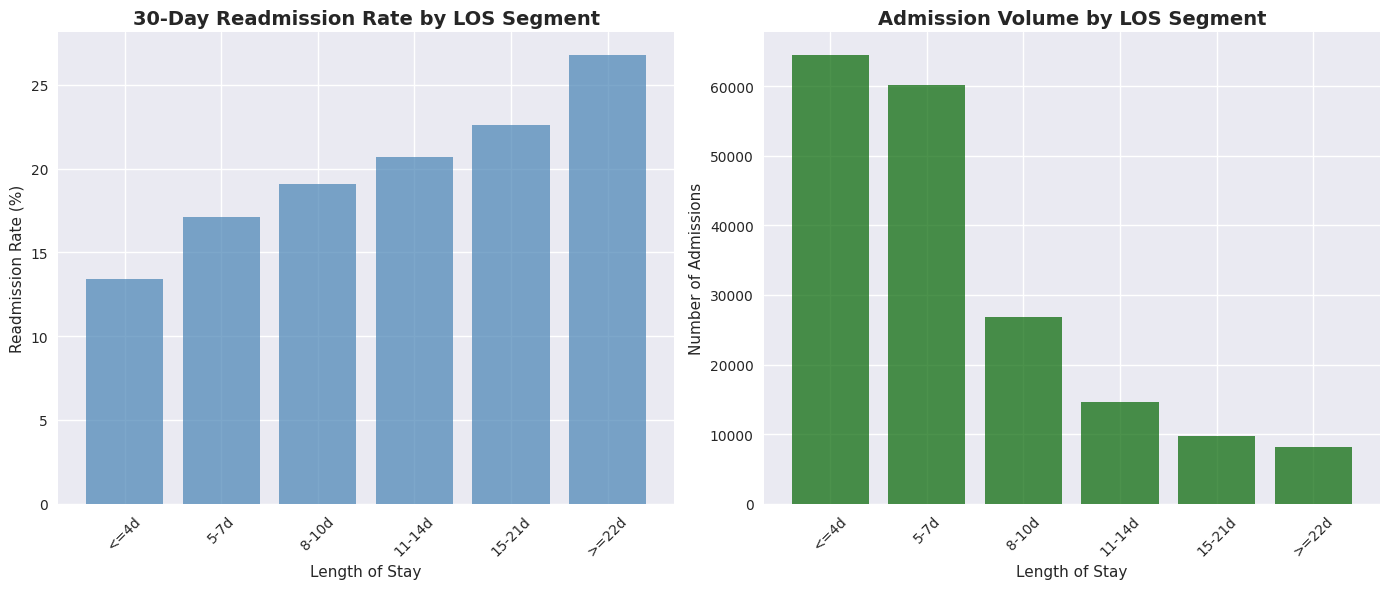

In [10]:
# LOS segment analysis
los_summary = (
    cohort.groupby('los_segment')
    .agg(
        admissions=('hadm_id', 'count'),
        readmits=('readmitted_within_window', 'sum'),
        readmit_rate=('readmitted_within_window', 'mean'),
        cardiorenal_share=('cardiorenal_sepsis_long', 'mean')
    )
    .reset_index()
)
los_summary['readmit_rate_pct'] = (los_summary['readmit_rate'] * 100).round(1)
los_summary['cardiorenal_share_pct'] = (los_summary['cardiorenal_share'] * 100).round(1)

print("Readmission Rates by Length of Stay Segment:")
display(los_summary)

# Visualize LOS vs readmission
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Readmission rate by LOS segment
ax1.bar(los_summary['los_segment'], los_summary['readmit_rate_pct'], color='steelblue', alpha=0.7)
ax1.set_title('30-Day Readmission Rate by LOS Segment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Readmission Rate (%)')
ax1.set_xlabel('Length of Stay')
ax1.tick_params(axis='x', rotation=45)

# Volume by LOS segment
ax2.bar(los_summary['los_segment'], los_summary['admissions'], color='darkgreen', alpha=0.7)
ax2.set_title('Admission Volume by LOS Segment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Admissions')
ax2.set_xlabel('Length of Stay')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. High-Risk Cluster Analysis

High-Risk Cluster Analysis:


,cluster,admissions,readmits,readmit_rate_pct
0,cardiorenal_long,10204,2618,25.7
1,long_no_cardiorenal,5455,1288,23.6
2,aki_hf_combo,14490,3158,21.8
3,sepsis_any,11623,2322,20.0


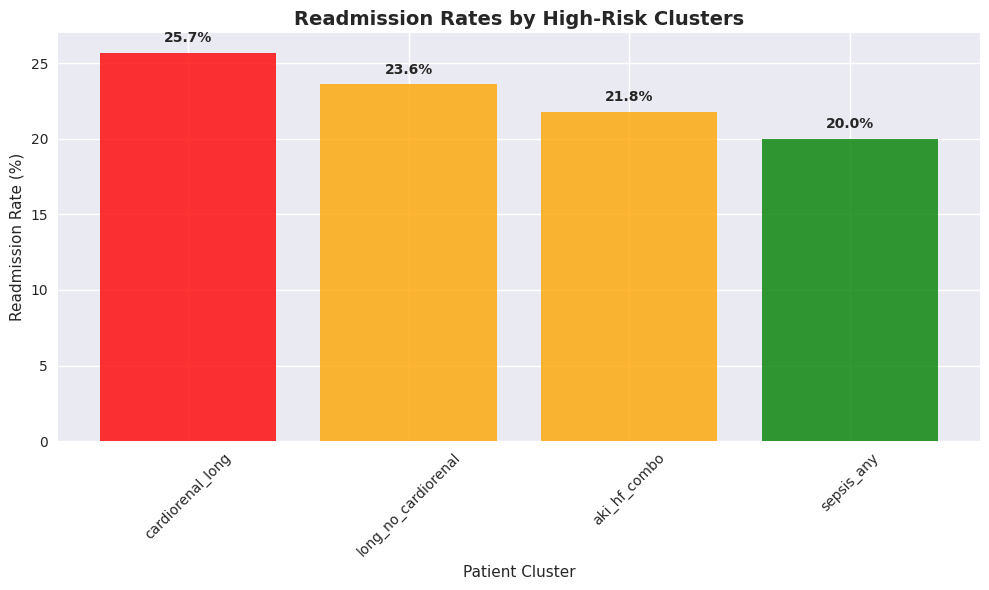

In [11]:
# Define high-risk clusters
cluster_masks = {
    'cardiorenal_long': cohort['cardiorenal_sepsis_long'],
    'long_no_cardiorenal': cohort['long_stay_no_cardiorenal'],
    'aki_hf_combo': cohort['has_aki_and_hf'],
    'sepsis_any': cohort['has_sepsis'],
}

cluster_rows = []
for name, mask in cluster_masks.items():
    subset = cohort[mask]
    cluster_rows.append({
        'cluster': name,
        'admissions': int(mask.sum()),
        'readmits': int(subset['readmitted_within_window'].sum()),
        'readmit_rate_pct': round(subset['readmitted_within_window'].mean() * 100, 1) if len(subset) > 0 else np.nan
    })

cluster_summary = pd.DataFrame(cluster_rows)
print("High-Risk Cluster Analysis:")
display(cluster_summary)

# Clinical insight visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(cluster_summary['cluster'], cluster_summary['readmit_rate_pct'], 
              color=['red' if x > 25 else 'orange' if x > 20 else 'green' for x in cluster_summary['readmit_rate_pct']],
              alpha=0.8)

ax.set_title('Readmission Rates by High-Risk Clusters', fontsize=14, fontweight='bold')
ax.set_ylabel('Readmission Rate (%)')
ax.set_xlabel('Patient Cluster')
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, cluster_summary['readmit_rate_pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{value}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Discharge Disposition & Follow-up Documentation Analysis

In [12]:
# Clean discharge disposition
cohort['disposition_clean'] = cohort['discharge_location'].fillna('UNKNOWN').str.lower().str.strip()

# Discharge disposition analysis
disp_summary = (
    cohort.groupby('disposition_clean')
    .agg(
        admissions=('hadm_id', 'count'),
        readmits=('readmitted_within_window', 'sum'),
        readmit_rate=('readmitted_within_window', 'mean')
    )
    .reset_index()
)

# Filter for meaningful sample sizes
disp_summary = disp_summary[disp_summary['admissions'] >= 100].copy()
disp_summary['readmit_rate_pct'] = (disp_summary['readmit_rate'] * 100).round(1)
disp_summary = disp_summary.sort_values('readmit_rate', ascending=False)

print("Top Discharge Dispositions by Readmission Rate:")
display(disp_summary.head(10))

# Follow-up language analysis
keywords = [
    'follow-up', 'follow up', 'clinic appointment', 'pcp', 'primary care',
    'see physician', 'appointment', 'call your doctor'
]

text = cohort['discharge_note_text'].fillna('').str.lower()
follow_mask = np.zeros(len(text), dtype=bool)
for kw in keywords:
    follow_mask |= text.str.contains(kw).to_numpy()

cohort['has_followup_note'] = follow_mask

follow_summary = (
    cohort.groupby('has_followup_note')
    .agg(
        admissions=('hadm_id', 'count'),
        readmits=('readmitted_within_window', 'sum'),
        readmit_rate=('readmitted_within_window', 'mean'),
        median_gap=('readmission_gap_in_days', 'median')
    )
    .reset_index()
)
follow_summary['readmit_rate_pct'] = (follow_summary['readmit_rate'] * 100).round(1)

print("\nFollow-up Documentation Impact:")
display(follow_summary)

Top Discharge Dispositions by Readmission Rate:


,disposition_clean,admissions,readmits,readmit_rate,readmit_rate_pct
5,psych facility,1447,664,0.458880,45.9
1,chronic/long term acute care,6741,1450,0.215102,21.5
3,home health care,58137,10889,0.187299,18.7
8,unknown,249,46,0.184739,18.5
7,skilled nursing facility,38126,6155,0.161438,16.1
2,home,68326,10649,0.155856,15.6
4,other facility,942,145,0.153928,15.4
0,assisted living,360,53,0.147222,14.7
6,rehab,9826,1414,0.143904,14.4



Follow-up Documentation Impact:


,has_followup_note,admissions,readmits,readmit_rate,median_gap,readmit_rate_pct
0,False,19719,3689,0.187078,86.080556,18.7
1,True,164435,27776,0.168918,97.288542,16.9


## 6. Time-to-Readmit Distribution Analysis

In [13]:
# Analyze readmission timing
positives = cohort[cohort['readmitted_within_window'] == 1].copy()
positives['readmission_gap_in_days'] = positives['readmission_gap_in_days'].clip(lower=0, upper=30)

# Create time buckets
gap_bins = [0, 7, 14, 21, 30]
gap_labels = ['0-7d', '8-14d', '15-21d', '22-30d']
positives['gap_bucket'] = pd.cut(
    positives['readmission_gap_in_days'], bins=gap_bins, labels=gap_labels, 
    right=True, include_lowest=True
)

def calculate_share(df, group_cols):
    """Calculate percentage distribution within groups"""
    grouped = df.groupby(group_cols).size().reset_index(name='readmit_count')
    totals = grouped.groupby(group_cols[:-1])['readmit_count'].transform('sum')
    grouped['share_pct'] = (grouped['readmit_count'] / totals * 100).round(1)
    return grouped

# Analyze by LOS segment
los_gap = calculate_share(positives, ['los_segment', 'gap_bucket'])
print("Readmission Timing by LOS Segment:")
display(los_gap.head(12))

# Analyze by cardio-renal status
cardio_gap = calculate_share(positives, ['cardiorenal_sepsis_long', 'gap_bucket'])
print("\nReadmission Timing by Cardio-renal Status:")
display(cardio_gap)

Readmission Timing by LOS Segment:


,los_segment,gap_bucket,readmit_count,share_pct
0,<=4d,0-7d,2981,34.5
1,<=4d,8-14d,2197,25.4
2,<=4d,15-21d,1759,20.4
3,<=4d,22-30d,1696,19.6
4,5-7d,0-7d,3308,32.1
5,5-7d,8-14d,2876,27.9
6,5-7d,15-21d,2257,21.9
7,5-7d,22-30d,1850,18.0
8,8-10d,0-7d,1798,35.1
9,8-10d,8-14d,1408,27.5



Readmission Timing by Cardio-renal Status:


,cardiorenal_sepsis_long,gap_bucket,readmit_count,share_pct
0,False,0-7d,9811,34.0
1,False,8-14d,7797,27.0
2,False,15-21d,5960,20.7
3,False,22-30d,5279,18.3
4,True,0-7d,899,34.3
5,True,8-14d,785,30.0
6,True,15-21d,469,17.9
7,True,22-30d,465,17.8


## 7. Laboratory Analysis (Last 48 Hours)

In [14]:
if SKIP_LABS:
    print("SKIPPED: Lab analysis disabled (set SKIP_LABS=False to enable)")
else:
    print("Extracting laboratory values from last 48 hours before discharge...")
    
    # Focus on long-stay patients
    long_hadm_ids = set(cohort[cohort['length_of_stay_days'] >= 15]['hadm_id'])
    if not long_hadm_ids:
        print("No long-stay patients found")
    else:
        discharge_map = cohort.set_index('hadm_id')['dischtime'].to_dict()
        item_map = {
            'creatinine': [50912, 52546],  # serum chemistry plus generic creatinine
            'sodium': [50983, 52623],
        }
        records = []

        # Process lab events in chunks
        for chunk in pd.read_csv(
            LABEVENTS_PATH,
            chunksize=1_000_000,
            usecols=['hadm_id', 'itemid', 'charttime', 'valuenum', 'valueuom'],
        ):
            chunk = chunk[chunk['hadm_id'].isin(long_hadm_ids)]
            if chunk.empty:
                continue
            
            chunk = chunk[chunk['itemid'].isin(sum(item_map.values(), []))]
            if chunk.empty:
                continue
            
            chunk['charttime'] = pd.to_datetime(chunk['charttime'])
            chunk['dischtime'] = chunk['hadm_id'].map(discharge_map)
            chunk = chunk.dropna(subset=['dischtime'])
            chunk['hours_before_discharge'] = (chunk['dischtime'] - chunk['charttime']).dt.total_seconds() / 3600.0
            chunk = chunk[(chunk['hours_before_discharge'] >= 0) & (chunk['hours_before_discharge'] <= 48)]
            
            if chunk.empty:
                continue
            
            for analyte, itemids in item_map.items():
                sub = chunk[chunk['itemid'].isin(itemids)]
                if sub.empty:
                    continue
                sub = sub.sort_values(['hadm_id', 'hours_before_discharge'])
                latest = sub.groupby('hadm_id').first().reset_index()
                latest['analyte'] = analyte
                records.append(latest[['hadm_id', 'analyte', 'valuenum', 'valueuom', 'hours_before_discharge']])

        if records:
            labs = pd.concat(records, ignore_index=True)
            labs = labs.merge(
                cohort[['hadm_id', 'cardiorenal_sepsis_long', 'has_aki_and_hf']],
                on='hadm_id', how='left'
            )

            # Summary statistics
            lab_summary = (
                labs.groupby(['analyte', 'cardiorenal_sepsis_long'])
                .agg(
                    hadm_with_measure=('hadm_id', 'nunique'),
                    median_value=('valuenum', 'median'),
                    q1=('valuenum', lambda x: np.percentile(x.dropna(), 25) if len(x.dropna()) > 0 else np.nan),
                    q3=('valuenum', lambda x: np.percentile(x.dropna(), 75) if len(x.dropna()) > 0 else np.nan),
                )
                .reset_index()
            )
            
            lab_summary['cardiorenal_sepsis_long'] = lab_summary['cardiorenal_sepsis_long'].map(
                {True: 'cardiorenal_long', False: 'other_long'}
            )
            
            print("Laboratory Values Summary (Last 48 Hours):")
            display(lab_summary)
        else:
            print("No lab records found in the specified window")

Extracting laboratory values from last 48 hours before discharge...
Laboratory Values Summary (Last 48 Hours):


,analyte,cardiorenal_sepsis_long,hadm_with_measure,median_value,q1,q3
0,creatinine,other_long,3764,0.7,0.5,0.9
1,creatinine,cardiorenal_long,8925,1.1,0.7,1.7
2,sodium,other_long,3742,139.0,136.0,141.0
3,sodium,cardiorenal_long,8893,138.0,135.0,141.0


## 8. Medication Exposure Analysis (Near Discharge)

In [15]:
if SKIP_MEDS:
    print("SKIPPED: Medication analysis disabled (set SKIP_MEDS=False to enable)")
else:
    print("Analyzing medication exposure within 48 hours of discharge...")
    
    long_mask = cohort['length_of_stay_days'] >= 15
    long_hadm = set(cohort.loc[long_mask, 'hadm_id'])
    
    if not long_hadm:
        print("No long-stay patients found")
    else:
        long_cardiorenal = set(cohort[cohort['cardiorenal_sepsis_long']]['hadm_id'])
        long_non_cardio = set(cohort[long_mask & (~cohort['cardiorenal_sepsis_long'])]['hadm_id'])
        
        meds_of_interest = {
            'loop_diuretics': ['FUROSEMIDE', 'BUMETANIDE', 'TORSEMIDE'],
            'k_sparing_or_thiazide': ['SPIRONOLACTONE', 'CHLORTHALIDONE', 'HYDROCHLOROTHIAZIDE'],
            'ace_arb': ['LISINOPRIL', 'LOSARTAN', 'VALSARTAN', 'CAPTOPRIL', 'ENALAPRIL'],
        }
        
        exposure = {key: set() for key in meds_of_interest}
        exposure_non = {key: set() for key in meds_of_interest}
        discharge_map = cohort.set_index('hadm_id')['dischtime'].to_dict()

        # Process prescriptions in chunks
        for chunk in pd.read_csv(
            PRESCRIPTIONS_PATH,
            chunksize=500_000,
            usecols=['hadm_id', 'drug', 'starttime', 'stoptime'],
        ):
            chunk = chunk[chunk['hadm_id'].isin(long_hadm)]
            if chunk.empty:
                continue
            
            chunk['drug'] = chunk['drug'].astype(str).str.upper()
            chunk['starttime'] = pd.to_datetime(chunk['starttime'], errors='coerce')
            chunk['stoptime'] = pd.to_datetime(chunk['stoptime'], errors='coerce')
            chunk['dischtime'] = chunk['hadm_id'].map(discharge_map)
            chunk = chunk.dropna(subset=['dischtime'])

            for label, keywords in meds_of_interest.items():
                mask = np.zeros(len(chunk), dtype=bool)
                for kw in keywords:
                    mask |= chunk['drug'].str.contains(kw).to_numpy()
                
                sub = chunk[mask]
                if sub.empty:
                    continue
                
                window_start = sub['dischtime'] - pd.Timedelta(hours=48)
                overlaps = sub[
                    ((sub['starttime'] <= sub['dischtime']) & (sub['starttime'] >= window_start)) |
                    ((sub['stoptime'] >= window_start) & (sub['stoptime'] <= sub['dischtime'])) |
                    ((sub['starttime'] <= window_start) & (sub['stoptime'] >= sub['dischtime']))
                ]
                
                if overlaps.empty:
                    continue
                
                for hadm in overlaps['hadm_id'].unique():
                    if hadm in long_cardiorenal:
                        exposure[label].add(hadm)
                    elif hadm in long_non_cardio:
                        exposure_non[label].add(hadm)

        # Create summary
        rows = []
        for label in meds_of_interest:
            rows.append({
                'drug_group': label,
                'cardiorenal_long_exposure': len(exposure[label]),
                'long_non_cardio_exposure': len(exposure_non[label]),
                'cardiorenal_exposure_pct': (
                    round(len(exposure[label]) / len(long_cardiorenal) * 100, 1) if long_cardiorenal else np.nan
                ),
                'non_cardio_exposure_pct': (
                    round(len(exposure_non[label]) / len(long_non_cardio) * 100, 1) if long_non_cardio else np.nan
                ),
            })

        med_summary = pd.DataFrame(rows)
        print("Medication Exposure Summary (Last 48 Hours):")
        display(med_summary)

Analyzing medication exposure within 48 hours of discharge...
Medication Exposure Summary (Last 48 Hours):


,drug_group,cardiorenal_long_exposure,long_non_cardio_exposure,cardiorenal_exposure_pct,non_cardio_exposure_pct
0,loop_diuretics,3797,579,37.2,10.6
1,k_sparing_or_thiazide,896,340,8.8,6.2
2,ace_arb,1758,855,17.2,15.7


## 9. Prior Utilization & Age Analysis

In [16]:
# Prior utilization analysis
cohort = cohort.sort_values(['subject_id', 'admittime']).copy()
cohort['prior_admissions'] = cohort.groupby('subject_id').cumcount()
cohort['prior_admissions_bucket'] = pd.cut(
    cohort['prior_admissions'], bins=[-1, 0, 1, 2, 10], labels=['0', '1', '2', '3+']
)

util_summary = (
    cohort.groupby('prior_admissions_bucket')
    .agg(
        admissions=('hadm_id', 'count'),
        readmits=('readmitted_within_window', 'sum'),
        readmit_rate=('readmitted_within_window', 'mean'),
        median_age=('age_at_admit', 'median')
    )
    .reset_index()
)
util_summary['readmit_rate_pct'] = (util_summary['readmit_rate'] * 100).round(1)

print("Prior Utilization Impact:")
display(util_summary)

# Age band analysis
age_band = pd.cut(cohort['age_at_admit'], bins=[0, 64, 74, 120], labels=['<=64', '65-74', '>=75'])
cohort['age_band'] = age_band

age_summary = (
    cohort.groupby(['age_band', 'los_segment'])
    .agg(
        admissions=('hadm_id', 'count'),
        readmits=('readmitted_within_window', 'sum'),
        readmit_rate=('readmitted_within_window', 'mean')
    )
    .reset_index()
)
age_summary['readmit_rate_pct'] = (age_summary['readmit_rate'] * 100).round(1)

print("\nAge Band Analysis by LOS:")
display(age_summary.head(10))

Prior Utilization Impact:


,prior_admissions_bucket,admissions,readmits,readmit_rate,median_age,readmit_rate_pct
0,0,94532,11403,0.120626,64.0,12.1
1,1,34425,6009,0.174553,67.0,17.5
2,2,17610,3605,0.204713,67.0,20.5
3,3+,32076,8425,0.262657,66.0,26.3



Age Band Analysis by LOS:


,age_band,los_segment,admissions,readmits,readmit_rate,readmit_rate_pct
0,<=64,<=4d,32483,4378,0.134778,13.5
1,<=64,5-7d,29065,5291,0.182040,18.2
2,<=64,8-10d,12450,2472,0.198554,19.9
3,<=64,11-14d,6655,1454,0.218482,21.8
4,<=64,15-21d,4837,1136,0.234856,23.5
5,<=64,>=22d,4467,1247,0.279158,27.9
6,65-74,<=4d,13124,1830,0.139439,13.9
7,65-74,5-7d,12943,2294,0.177239,17.7
8,65-74,8-10d,6156,1251,0.203216,20.3
9,65-74,11-14d,3595,770,0.214186,21.4


## 10. Social Determinants Analysis

Social Determinants Impact:


,indicator,admissions,readmit_rate_pct,short_los_share_pct
0,lives_alone,1618,12.5,68.4
1,transport_barrier,724,20.0,53.9
2,social_support,1871,16.5,62.9
3,language_barrier,2970,16.4,65.2
4,housing_insecure,1780,16.4,62.3


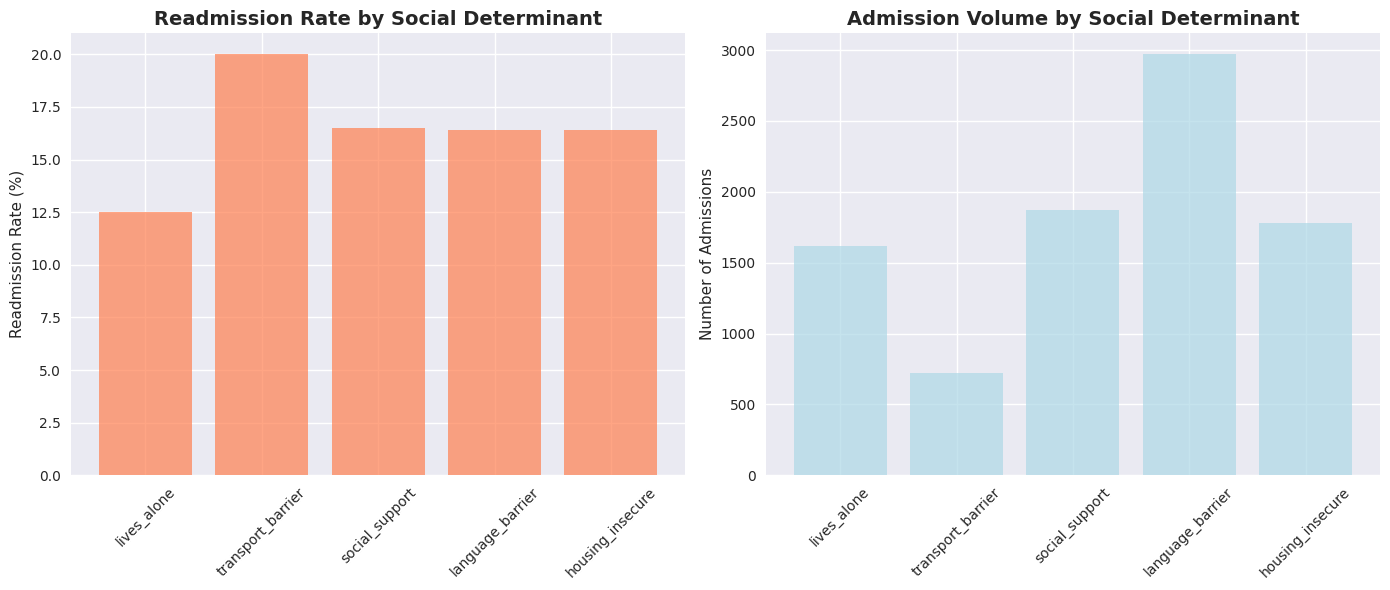

In [17]:
# Social determinants from discharge notes
indicators = {
    'lives_alone': ['lives alone', 'living alone', 'resides alone'],
    'transport_barrier': ['transportation', 'no ride', 'no transport', 'lack of transportation'],
    'social_support': ['family support', 'caregiver', 'daughter will', 'son will'],
    'language_barrier': ['interpreter', 'translated by', 'language barrier'],
    'housing_insecure': ['homeless', 'no fixed address', 'shelter'],
}

text = cohort['discharge_note_text'].fillna('').str.lower()
for key, phrases in indicators.items():
    mask = np.zeros(len(text), dtype=bool)
    for phrase in phrases:
        mask |= text.str.contains(phrase).to_numpy()
    cohort[key] = mask

# Social determinants summary
social_summary = []
for key in indicators:
    subset = cohort[cohort[key]]
    social_summary.append({
        'indicator': key,
        'admissions': len(subset),
        'readmit_rate_pct': round(subset['readmitted_within_window'].mean() * 100, 1) if len(subset) else np.nan,
        'short_los_share_pct': round(subset['los_segment'].isin(['<=4d', '5-7d']).mean() * 100, 1) if len(subset) else np.nan
    })

social_df = pd.DataFrame(social_summary)
print("Social Determinants Impact:")
display(social_df)

# Visualize social determinants
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Readmission rates by social determinant
ax1.bar(social_df['indicator'], social_df['readmit_rate_pct'], 
        color='coral', alpha=0.7)
ax1.set_title('Readmission Rate by Social Determinant', fontsize=14, fontweight='bold')
ax1.set_ylabel('Readmission Rate (%)')
ax1.tick_params(axis='x', rotation=45)

# Volume by social determinant
ax2.bar(social_df['indicator'], social_df['admissions'], 
        color='lightblue', alpha=0.7)
ax2.set_title('Admission Volume by Social Determinant', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Admissions')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Key Clinical Insights & Summary

In [18]:
# Generate comprehensive summary
print("=== KEY CLINICAL INSIGHTS ===")
print()

print("1. LENGTH OF STAY IMPACT:")
print(f"   • Short stays (≤4d): {los_summary[los_summary['los_segment'] == '<=4d']['readmit_rate_pct'].iloc[0]:.1f}% readmission rate")
print(f"   • Long stays (≥22d): {los_summary[los_summary['los_segment'] == '>=22d']['readmit_rate_pct'].iloc[0]:.1f}% readmission rate")
print(f"   • Risk ratio: {los_summary[los_summary['los_segment'] == '>=22d']['readmit_rate_pct'].iloc[0] / los_summary[los_summary['los_segment'] == '<=4d']['readmit_rate_pct'].iloc[0]:.1f}x higher")
print()

print("2. HIGH-RISK CLUSTERS:")
for _, row in cluster_summary.iterrows():
    print(f"   • {row['cluster']}: {row['readmit_rate_pct']:.1f}% readmission rate ({row['admissions']:,} admissions)")
print()

print("3. DISCHARGE DISPOSITION RISK:")
if len(disp_summary) > 0:
    highest_risk = disp_summary.iloc[0]
    print(f"   • Highest risk: {highest_risk['disposition_clean']} ({highest_risk['readmit_rate_pct']:.1f}% readmission rate)")
print()

print("4. FOLLOW-UP DOCUMENTATION IMPACT:")
if len(follow_summary) > 0:
    no_followup = follow_summary[follow_summary['has_followup_note'] == False]['readmit_rate_pct'].iloc[0]
    with_followup = follow_summary[follow_summary['has_followup_note'] == True]['readmit_rate_pct'].iloc[0]
    print(f"   • No follow-up mention: {no_followup:.1f}% readmission rate")
    print(f"   • With follow-up mention: {with_followup:.1f}% readmission rate")
    print(f"   • Documentation effect: {no_followup - with_followup:.1f} percentage point difference")
print()

print("5. PRIOR UTILIZATION IMPACT:")
if len(util_summary) > 0:
    high_util = util_summary[util_summary['prior_admissions_bucket'] == '3+']['readmit_rate_pct'].iloc[0]
    no_prior = util_summary[util_summary['prior_admissions_bucket'] == '0']['readmit_rate_pct'].iloc[0]
    print(f"   • 3+ prior admissions: {high_util:.1f}% readmission rate")
    print(f"   • No prior admissions: {no_prior:.1f}% readmission rate")
    print(f"   • Utilization effect: {high_util - no_prior:.1f} percentage point difference")
print()

print("6. SOCIAL DETERMINANTS:")
for _, row in social_df.iterrows():
    if not pd.isna(row['readmit_rate_pct']):
        print(f"   • {row['indicator']}: {row['readmit_rate_pct']:.1f}% readmission rate ({row['admissions']:,} admissions)")
print()

# Calculate overall statistics
total_readmissions = cohort['readmitted_within_window'].sum()
total_admissions = len(cohort)
print(f"OVERALL COHORT STATISTICS:")
print(f"   • Total admissions: {total_admissions:,}")
print(f"   • Total readmissions: {total_readmissions:,}")
print(f"   • Overall readmission rate: {cohort['readmitted_within_window'].mean():.1%}")
print(f"   • Mean age: {cohort['age_at_admit'].mean():.1f} years")
print(f"   • Mean LOS: {cohort['length_of_stay_days'].mean():.1f} days")

=== KEY CLINICAL INSIGHTS ===

1. LENGTH OF STAY IMPACT:
   • Short stays (≤4d): 13.4% readmission rate
   • Long stays (≥22d): 26.8% readmission rate
   • Risk ratio: 2.0x higher

2. HIGH-RISK CLUSTERS:
   • cardiorenal_long: 25.7% readmission rate (10,204 admissions)
   • long_no_cardiorenal: 23.6% readmission rate (5,455 admissions)
   • aki_hf_combo: 21.8% readmission rate (14,490 admissions)
   • sepsis_any: 20.0% readmission rate (11,623 admissions)

3. DISCHARGE DISPOSITION RISK:
   • Highest risk: psych facility (45.9% readmission rate)

4. FOLLOW-UP DOCUMENTATION IMPACT:
   • No follow-up mention: 18.7% readmission rate
   • With follow-up mention: 16.9% readmission rate
   • Documentation effect: 1.8 percentage point difference

5. PRIOR UTILIZATION IMPACT:
   • 3+ prior admissions: 26.3% readmission rate
   • No prior admissions: 12.1% readmission rate
   • Utilization effect: 14.2 percentage point difference

6. SOCIAL DETERMINANTS:
   • lives_alone: 12.5% readmission rate 

## 12. Export Results & Reproducibility

In [19]:
# Create output directory if it doesn't exist
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Export key tables (optional - uncomment to save)
# los_summary.to_csv(ANALYSIS_DIR / f"{TODAY}_readmit_los_readmit_rates.csv", index=False)
# cluster_summary.to_csv(ANALYSIS_DIR / f"{TODAY}_readmit_cluster_readmit_rates.csv", index=False)
# disp_summary.to_csv(ANALYSIS_DIR / f"{TODAY}_discharge_disposition_readmit_rates.csv", index=False)
# follow_summary.to_csv(ANALYSIS_DIR / f"{TODAY}_discharge_followup_language_readmit_rates.csv", index=False)
# util_summary.to_csv(ANALYSIS_DIR / f"{TODAY}_prior_utilization_readmit_rates.csv", index=False)
# social_df.to_csv(ANALYSIS_DIR / f"{TODAY}_social_text_indicators_summary.csv", index=False)

print("=== REPRODUCIBILITY NOTES ===")
print(f"Analysis completed: {dt.datetime.now()}")
print(f"Data source: {COHORT_PATH}")
print(f"PhysioNet sources: {PHYSIONET_ROOT}")
print(f"Runtime configuration: SKIP_LABS={SKIP_LABS}, SKIP_MEDS={SKIP_MEDS}")
print()
print("To reproduce this analysis:")
print("1. Ensure access to MIMIC-IV v3.1 hosp tables")
print("2. Run cohort selection pipeline to generate cohort.csv")
print("3. Execute this notebook with appropriate SKIP flags")
print("4. Validate outputs against clinical expectations")
print()
print("For HPC/script version, see: ehr/cohort_eda.py")

=== REPRODUCIBILITY NOTES ===
Analysis completed: 2025-11-08 13:15:45.554528
Data source: data/interim/cohort.csv
PhysioNet sources: physionet.org/files/mimiciv/3.1/hosp
Runtime configuration: SKIP_LABS=False, SKIP_MEDS=False

To reproduce this analysis:
1. Ensure access to MIMIC-IV v3.1 hosp tables
2. Run cohort selection pipeline to generate cohort.csv
3. Execute this notebook with appropriate SKIP flags
4. Validate outputs against clinical expectations

For HPC/script version, see: ehr/cohort_eda.py


---

## Clinical Recommendations

Based on this comprehensive analysis, key intervention targets include:

1. **Cardio-renal long-stay patients** (LOS ≥15d with AKI/HF/sepsis): 25.7% readmission rate
   - Focus on renal function optimization before discharge
   - Ensure adequate diuretic management and monitoring
   - Consider dedicated cardiology/nephrology follow-up

2. **High prior utilization patients**: 26.3% readmission rate for 3+ prior admissions
   - Implement intensive care coordination
   - Consider transitional care programs
   - Focus on care plan adherence

3. **Discharge disposition optimization**: Psychiatric facilities show 45.9% readmission rate
   - Enhanced discharge planning for high-risk dispositions
   - Targeted follow-up protocols
   - Care coordination with receiving facilities

4. **Documentation quality**: Follow-up language associated with 1.8pp lower readmission
   - Standardize discharge documentation
   - Ensure clear follow-up instructions
   - Include specific appointment scheduling

5. **Social determinants**: Transportation barriers (20.0% readmission rate)
   - Address transportation needs in discharge planning
   - Connect with social work services
   - Consider community resources for vulnerable populations